In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
from pydantic import BaseModel, Field
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", google_api_key=api_key, temperature=0.7)

Google api key is set


In [9]:
from langchain_core.tools import tool
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
import shutil

@tool
def create_file(name: str, file_path: str) -> str:
    """Tool for Creating new Files and Folders"""
    try:
        os.makedirs(file_path, exist_ok=True)

        full_path = os.path.join(file_path, name)

        with open(full_path, "w", encoding="utf-8") as f:
            pass

        return f"File created successfully at file path:{file_path}"
    
    except Exception as e:
        return f"Error: {e}"

@tool
def read_file(name: str, file_path: str) -> str:
    """Tool for Reading Files"""
    try:
        os.mkdirs(file_path, exist_ok=True)

        full_path = os.path.join(file_path, name)
        with open(full_path, "r", encoding="utf-8") as f:
            pass

        return f"File loaded successfully from file path:{file_path}"

    except Exception as e:
        return f"Error: {e}"

@tool
def read_pdf( file_path: str) -> str:
    """
    Tool to read pdf docs
    Args:
        file_path: path of the document to read
    """
    try:
        if not os.path.exists(file_path):
            return f"File destination does not exists"

        document = PyMuPDFLoader(file_path)

        pdf_document = document.load()
        text = "\n".join(docs.page_content for docs in pdf_document)
        return text

    except Exception as e:
        return f"Error: {e}"

@tool
def write_file(name: str, file_path: str, content: str) -> str:
    """Tool for Writing into Files"""
    try:
        full_path = os.path.join(file_path, name)
        with open(full_path, "w", encoding="utf-8") as f:
            f.write(content)

        return f"File written successfully at file path:{file_path}"

    except Exception as e:
        return f"Error: {e}"

@tool
def move_file(source_path: str, destination_path: str) -> str:
    """
    Tool for moving Files or Folder from one location to another
    Args:
        source_path: Full path of the file or folder to move.
        destination_path: Destination directory or full destination path.
    """
    try:
        if not os.path.exists(source_path):
            return f"Source does not exists {source_path}"

        if not os.path.isdir(destination_path):
            return f"Destination does not exists {destination_path}"

        new_path = shutil.move(source_path, destination_path)

        return f"Succesfully move to: {new_path}"

    except Exception as e:
        return f"Error: {e}"
    
@tool
def list_file(folder_path: str) -> str:
    """Tool for Listing all Files in a folder"""
    try:
        if not os.path.isdir(folder_path):
            return f"Error Folder not found: {folder_path}"

        items = os.listdir(folder_path)

        if not items:
            return f"Folder is empty: {folder_path}"

        output = []

        for item in items:

            full_path = os.path.join(folder_path, item)
            if os.path.isdir(full_path):
                output.append(f"item: {item}")
            else:
                output.append(f"item: {item}")

        return "\n".join(output)

    except Exception as e:
        return f"Error: {e}"

@tool
def rename_file(item_path: str, new_name: str):
    """
    Tool for Renaming Files
    
    Args:
        item_path: Full path of the file or folder.
        new_name: New name (not the full path).
    """
    try:
        if not os.path.exists(item_path):
            return f"Error: {item_path} does not exists"

        parent_directory = os.path.dirname(item_path)
        new_path = os.path.join(parent_directory, new_name)

        os.rename(item_path, new_path)

        return f"Successfully renamed to: {new_name}"

    except Exception as e:
        return f"Error: {e}"
@tool
def copy_file(source_path: str, destination_path: str):
    """
    Tool for copying Files or Folder
    Args:
        source_path: Full path of the file or folder to copy.
        destination_path: Destination folder where the item will be copied.
    """
    try:
        if not os.path.exists(source_path):
            return f"Source file does not exists"
        if not os.path.isdir(destination_path):
            return f"Destination folder {destination_path} does not exists"

        filename = os.path.basename(source_path)

        new_path = os.path.join(destination_path, filename)

        if os.path.exists(new_path):
            return f"Error: {new_path} already exists"

        if os.path.isfile(source_path):
            shutil.copy2(source_path, new_path)

        elif os.path.isdir(source_path):
            shutil.copytree(source_path, new_path)

        return f"Succesfully copied to: {new_path}"

    except Exception as e:
        return f"Error: {e}"

@tool
def delete_file(item_path: str) -> str:
    """
    Tool for deleting Files and Folder
    Args:
        item_path: Full path of the file or folder to delete.
    """
    try:
        if not os.path.exists:
            return f"File {item_path} does not exists"

        if os.path.isfile(item_path):
            os.remove(item_path)
            return f"File deleted successfully: {item_path}"

        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            return f"Folder deleted successfully: {item_path}"

        else:
            return f"Unknown item type."

    except Exception as e:
        return f"Error: {e}"

@tool
def search_file(search_path: str, item_name) -> str:
    """
    Search for a file or folder inside a directory and its subdirectories.

    Args:
        search_path: Directory where the search should start.
        item_name: Name of the file or folder to search for.
    """
    try:
        if not os.path.isdir(search_path):
            return f"Error {search_path} is not a valid directory"
        
        matches = []
        
        for root, dirs, files in os.walk(search_path):
            for directory in dirs:
                if(directory.lower() == item_name.lower()):
                        matches.append(os.path.join(root, directory))
        
            for file in files:
                if(file.lower() == item_name.lower()):
                    matches.append(os.path.join(root, file))
        
        if not matches:
            return f"No file or folder named '{item_name}' was found."
        
        return "\n".join(matches)
        
    
    except Exception as e:
        return f"Error: {e}"

In [10]:
tools = [create_file, read_file, read_pdf, write_file, move_file, delete_file,list_file, rename_file, copy_file, search_file]

llm_with_tools = llm.bind_tools(tools)


In [11]:
from typing import TypedDict,List, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [12]:
def graph_node(state: graph_schema) -> graph_schema:
    message = state['messages']
    response = llm_with_tools.invoke(message)
    return {
        "messages": [response]
    }

def tool_node(state: graph_schema) -> graph_schema:
    message = state['messages']
    tools_by_name = {tool.name: tool for tool in tools}
    tool_result = []

    for tool_call in message[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        tool_result.append(ToolMessage(content=str(result), tool_call_id=tool_call["id"]))

    return {
        "messages": tool_result
    }

def if_tool_call(state: graph_schema) -> str:
    message = state['messages']

    if message[-1].tool_calls:
        return "tool_node"
    else:
        return "end"

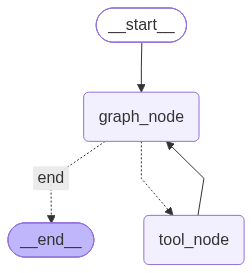

In [13]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("graph_node", graph_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "graph_node")
graph.add_conditional_edges("graph_node", if_tool_call, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "graph_node")
graph.add_edge("graph_node", END)

file_graph = graph.compile()
file_graph

In [14]:
result = file_graph.invoke({"messages":[HumanMessage(content=r"Read the pdf FaheemJawaidResume in Secret_Folder inside Desktop inside C drive Users Fahee One drive")]})
result

c:\FAHEEM\My_Programs\AI Agents\practice_AI_Agents\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\FAHEEM\My_Programs\AI Agents\practice_AI_Agents\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\FAHEEM\My_Programs\AI Agents\practice_AI_Agents\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\FAHEEM\My_Programs\AI Agents\practice_AI_Agents\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flas

{'messages': [HumanMessage(content='Read the pdf FaheemJawaidResume in Secret_Folder inside Desktop inside C drive Users Fahee One drive', additional_kwargs={}, response_metadata={}, id='2a9a48ca-5940-4416-996f-d1455fdb2312'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_file', 'arguments': '{"search_path": "C:/Users/Fahee", "item_name": "FaheemJawaidResume"}'}, '__gemini_function_call_thought_signatures__': {'v88ij7GS': 'EvUHCvIHARFNMg8leadSR9cCzIF5QMgQY52+W5xLpBbgv2rKLcnPhSsxhbtZrf06gqsaGTSRQPf3cD/GV9lk6KzDABtdYCToRT4D+5oQf7hwqDrooMA513ultI2OcPFo8eGDFdpiTXhLp6MJgjeK7qXrBePs8LYK+QZX1OEFhTAg5x1bLDP4wOByp624lNhjyvEILXy37uTS0bZBJj0TX5otz1OBQlbd32ZRnxKl+WrsfNcmgS9zmCKdkEcDPDq3NQvftRUm0BAusf+rkp+EUhCFldbC83yPtgh6WHmmgmF4jEOS8ImgSeyP/5dyVZqK1zGmhf5yDah8fvG/ddLZ9ejnHEuxWmWgc2ajSPwEcnXUeJ0jfrFZod+3toPV1f0iKyOXuLjxknvfkRjSColAuogSGmmKJJ+WEZobHUlrj/kLHf5+cGJpGmyNe7+Nh4bgDQGEJCF3N+TZObFdQH1wQ1ygYux9q7rQXB6CV9bfx+gjRVd6FdsHV7zlUiChpsGUcbryhePWv1zp4HgRPwowMYC74vL+JS